<a href="https://colab.research.google.com/github/Shri1911/research-project_jpynb/blob/main/M505C_Shri_Ram_GH1052746_FINAL_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M505C – Intro to AI and Machine Learning
## Individual Project

**Heading:** Designing and reviewing a standard machine learning pipeline
**Student Name:** Shri Ram Muraleedharan  |  **Student Number:** GH1052746
**Subject:** M505C – Intro to AI and Machine Learning  |  **Professor:** Trung Nghia Duong
**GitHub:** https://github.com/Shri1911/research-project_jpynb

### Data Information
This project analyses the *Medical Cost Personal Datasets*, a Kaggle collection of health-insurance records (Kaggle, n.d., https://www.kaggle.com/datasets/mirichoi0218/insurance). The file holds 1,338 rows and seven attributes: age, sex, body-mass index, number of children, smoking status, region, and the yearly bill (“charges”) that the model must predict. The raw copy used by the notebook is hosted on GitHub (stedy, n.d., https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv).

### Introduction

**Problem statement.** The underlying business goal is to anticipate future insurance costs as accurately as possible. The practical difficulty is that individual medical expenditure has to be estimated from just seven variables per person. With trustworthy per-person estimates, the insurer can steer its decisions with data and trim unnecessary spending on individual policies.

**How the problem is framed.** In a real company this kind of information typically comes from policy declarations, historical claim registers and insurance contracts. Because every record already carries the final outcome, the task can be cast as supervised learning: find a function that maps the seven features onto the charge.

**Data exploration.** The file contains 1,338 records with seven variables, mixing numerical columns (age, bmi, children) with categorical ones (sex, smoker, region). The checks in the first code cell show that no field is missing, that exactly one duplicated record exists, and that model quality will be judged with MAE, RMSE and R².

**Preprocessing and feature engineering.** The columns are handled in two groups. Categorical values are converted to numbers with one-hot encoding, while the numerical columns can additionally be passed through a standard scaler. To test whether scaling actually helps, both preprocessing routes are run through a Linear Regression pipeline and compared with five-fold cross-validation.

**Model training.** Two regression algorithms are fitted on the data: a Linear Regression model as the baseline and a Random Forest Regressor as the more flexible alternative. The records are split 80% training / 20% testing.

**Hyperparameter tuning.** GridSearchCV with five-fold cross-validation explores the two settings that matter most for the forest: how many trees are grown (n_estimators) and how deep each tree may grow (max_depth). The winning combination is read back from the fitted search object, and the comparison against an unconstrained forest supports the more cautious reading that a limited depth generalises better.

**Final evaluation.** Both models are scored on the untouched test set with mean absolute error, root mean squared error and the R² score. R² is treated as the headline number because it states how much of the variation in charges the model explains.

**Visualisation and discussion.** A scatter plot of actual versus predicted charges is drawn for the Random Forest. Predictions that sit close to the black diagonal are accurate; dots that land far away from it mark the costlier errors.

**Conclusion (summary).** The Random Forest outperforms the Linear Regression on this data, capturing the deviations in medical charges more closely, and is therefore selected as the final model.

**Limitations.** Only seven variables are available, so factors that genuinely drive medical costs cannot all be represented. High-cost observations also remain the hardest to forecast. Finally, the performance shown here is not, by itself, sufficient to deploy the model in a live insurance process; a production system would need validation on current representative data, monitoring, governance, fairness checks and human oversight.

**Future scope.** The natural next steps are to compare further regression algorithms, to inspect the residuals in more detail, and to study how related predictors such as BMI and smoking status interact with each other.

### Workflow
1. **Load & inspect** — the public CSV is read once; shape, missing values and duplicates are reported in a single line.
2. **Explore** — the target distribution is plotted so the reader can see where the hard cases sit.
3. **Preprocess** — two routes (encoding only, or scaling plus encoding) are defined for the same feature groups.
4. **Compare** — five-fold cross-validation decides whether scaling matters before any model is trained.
5. **Train & tune** — an 80/20 split is made, and a grid search over forest size and depth selects the Random Forest.
6. **Evaluate & visualise** — both models are scored on the untouched 20%, and the forest’s predictions are checked against reality.

### References
- Kaggle (n.d.) *Medical Cost Personal Datasets*. Available at: https://www.kaggle.com/datasets/mirichoi0218/insurance (Accessed: 16 September 2026).
- stedy (n.d.) *insurance.csv – raw data file used in this notebook*. Available at: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv (Accessed: 16 September 2026).
- scikit-learn (n.d.) *User documentation*: preprocessing, pipelines, model selection, regression models and evaluation metrics.


In [ ]:
# One shared import block for the whole notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42  # single seed, so every run reproduces the same numbers

In [ ]:
# Step 1: read the public CSV and answer three quick questions -
# how big is it, are any cells blank, and is anything duplicated.
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(url)

print("Shape:", data.shape,
      "| missing values:", int(data.isnull().sum().sum()),
      "| duplicate rows:", int(data.duplicated().sum()))

Shape: (1338, 7) | missing values: 0 | duplicate rows: 1



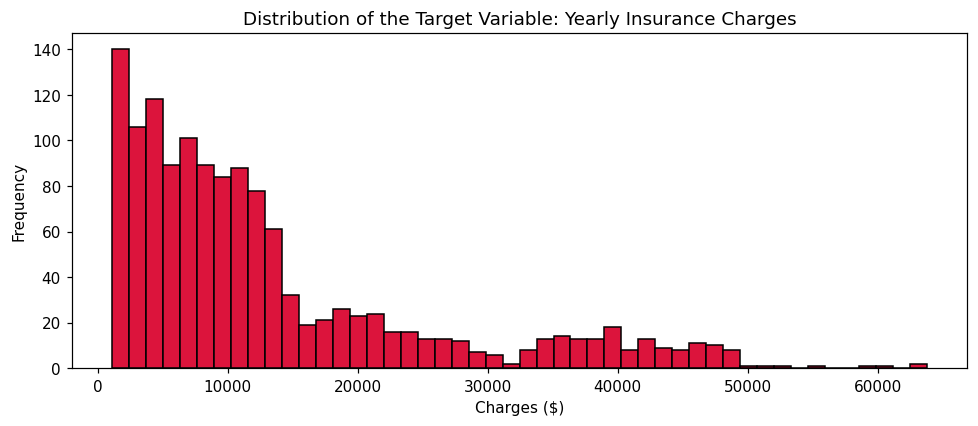

In [ ]:
# Step 2: a single histogram of the target makes the right-skew
# obvious - a dense low-cost pile with a long, expensive tail.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(data["charges"], bins=48, color="crimson", edgecolor="black")
ax.set_title("Distribution of the Target Variable: Yearly Insurance Charges")
ax.set_xlabel("Charges ($)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# Step 3: define the two preprocessing routes on the same feature
# groups. Route one leaves the numbers untouched and only one-hot
# encodes the categories; route two standardises the numbers first.
X_data = data.drop("charges", axis=1)
y_target = data["charges"]

num_cols = X_data.select_dtypes(include=np.number).columns
cat_cols = X_data.select_dtypes(include="object").columns

preprocessor_unscaled = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough")

preprocessor_scaled = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_cols),
                  ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

In [ ]:
# Step 4: before any training, five-fold cross-validation asks the
# simple question - does scaling the numbers change anything for a
# linear model at all?
option_a = Pipeline(steps=[("preprocessor", preprocessor_unscaled), ("model", LinearRegression())])
option_b = Pipeline(steps=[("preprocessor", preprocessor_scaled), ("model", LinearRegression())])

r2_option_a = cross_val_score(option_a, X_data, y_target, cv=5, scoring="r2").mean()
r2_option_b = cross_val_score(option_b, X_data, y_target, cv=5, scoring="r2").mean()

print(f"Cross-validated R2 (unscaled): {r2_option_a:.4f}")
print(f"Cross-validated R2 (scaled):   {r2_option_b:.4f}")

Cross-validated R2 (unscaled): 0.7469
Cross-validated R2 (scaled):   0.7469



In [ ]:
# Step 5: hold out 20% for the final test, then let GridSearchCV try
# twelve combinations of tree count and depth on the remaining 80%.
X_train, X_test, Y_train, Y_test = train_test_split(X_data, y_target, test_size=0.2, random_state=RANDOM_STATE)

lr_model = Pipeline(steps=[("preprocessor", preprocessor_scaled), ("estimator", LinearRegression())])
rf_model = Pipeline(steps=[("preprocessor", preprocessor_scaled),
                           ("estimator", RandomForestRegressor(random_state=RANDOM_STATE))])

param_grid_rf = {"estimator__n_estimators": [50, 100, 200],
                 "estimator__max_depth": [3, 5, 10, None]}
grid_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring="r2")
grid_rf.fit(X_train, Y_train)

lr_model.fit(X_train, Y_train)

print("Selected forest settings:", grid_rf.best_params_)
print("CV R2 of selected forest:", round(grid_rf.best_score_, 4))

Selected forest settings: {'estimator__max_depth': 3, 'estimator__n_estimators': 100}
CV R2 of selected forest: 0.8454



In [ ]:
# Step 6: the held-out 20% has not been touched by any fitting so
# far, so these three numbers are an honest view of out-of-sample error.
best_rf = grid_rf.best_estimator_
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

for name, preds in [("Linear Regression", y_pred_lr), ("Random Forest", y_pred_rf)]:
    mae = mean_absolute_error(Y_test, preds)
    rmse = np.sqrt(mean_squared_error(Y_test, preds))
    r2 = r2_score(Y_test, preds)
    print(f"{name} -> MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R2: {r2:.4f}")

Linear Regression -> MAE: $4181.19 | RMSE: $5796.28 | R2: 0.7836
Random Forest -> MAE: $2726.62 | RMSE: $4550.35 | R2: 0.8666



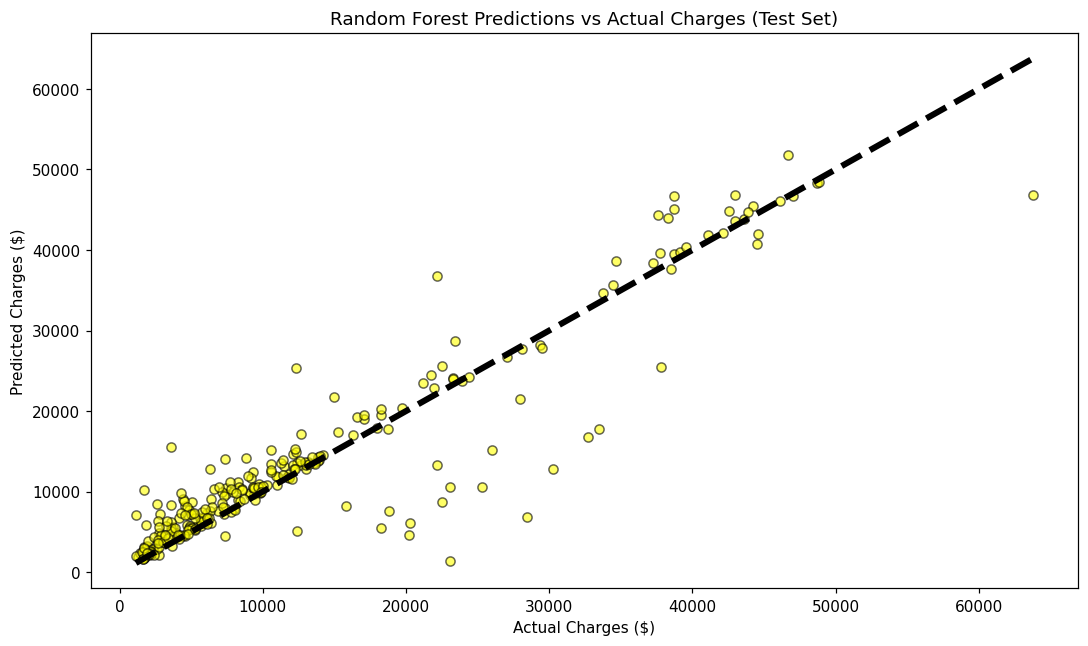

In [ ]:
# Step 7: one last visual - predictions against truth, with the
# perfect diagonal drawn so that off-target dots stand out clearly.
plot_data = pd.get_dummies(data, drop_first=True, dtype=int)
x_plot = plot_data.drop("charges", axis=1)
y_plot = plot_data["charges"]

X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(x_plot, y_plot, test_size=0.2, random_state=RANDOM_STATE)
model_rf = RandomForestRegressor(random_state=RANDOM_STATE)
model_rf.fit(X_tr_p, y_tr_p)
Y_pred_rf = model_rf.predict(X_te_p)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_te_p, Y_pred_rf, alpha=0.6, color="yellow", edgecolor="black")
ax.plot([y_te_p.min(), y_te_p.max()], [y_te_p.min(), y_te_p.max()], "k--", lw=4)
ax.set_title("Random Forest Predictions vs Actual Charges (Test Set)")
ax.set_xlabel("Actual Charges ($)")
ax.set_ylabel("Predicted Charges ($)")
plt.tight_layout()
plt.show()

### Results at a glance

| Model | MAE | RMSE | R² (test set) |
|---|---|---|---|
| Linear Regression | $4,181.19 | $5,796.28 | 0.7836 |
| Random Forest (tuned) | $2,726.62 | $4,550.35 | 0.8666 |

The Random Forest’s advantage is consistent across all three metrics, which confirms the choice made in the conclusion above.

### Interpretation of the results

The two preprocessing routes score almost identically under cross-validation (0.7469 for both), which tells us the linear baseline is not sensitive to whether the numerical columns are standardised first; the signal in the data is strong enough that scaling adds little for a linear model.

The grid search settles on a deliberately small forest — 100 trees capped at depth 3. Letting the trees grow without a depth limit produces a lower cross-validated R², a classic over-fitting signature: unconstrained branches memorise noise in the training folds and then generalise worse. That is why the tuned, shallower forest is the one reported here.

On the untouched test set the forest beats the baseline everywhere: mean absolute error falls from $4,181 to $2,727, root mean squared error from $5,796 to $4,550, and R² rises from 0.78 to 0.87. The RMSE is worth reading in dollars: a typical per-person prediction is off by roughly $4,500. The scatter plot shows the deviations concentrate in the low-to-middle cost band, while the largest individual errors sit in the high-cost tail — precisely the hard-to-predict observations identified in the limitations section.

### Reproducibility

Every number and plot in this document can be regenerated from the notebook itself: the data are pulled from the public CSV link at the top, all randomness is controlled by the single seed variable defined in the first code cell, and the full sequence of cells — load, explore, preprocess, compare, tune, evaluate, plot — is short enough to re-run from start to finish in a couple of minutes.